(3, 2)


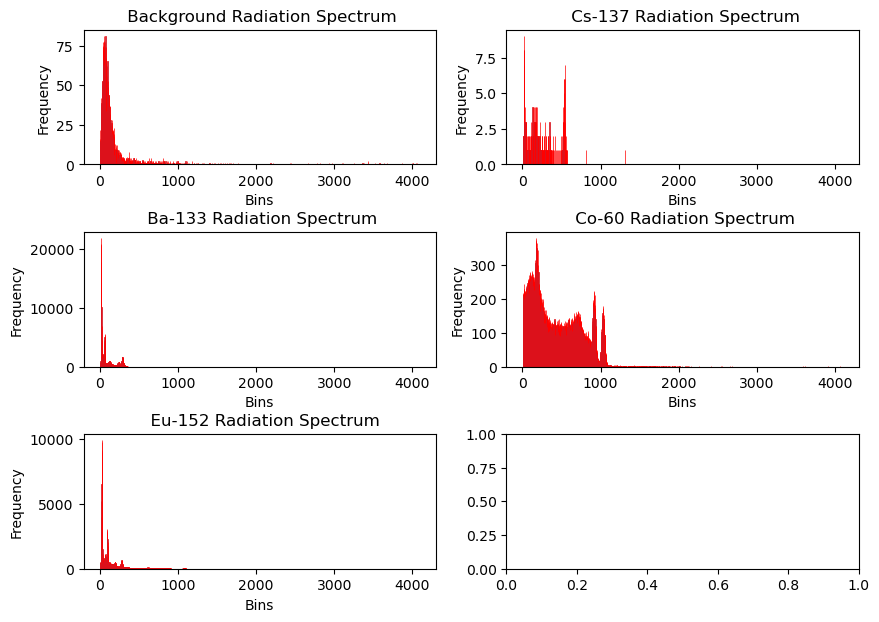

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

spectrum_data = [0,0,0,0,0]
isotopes = ["Background","Cs-137","Ba-133","Co-60"," Eu-152"]

spectrum_data[0] = pd.read_csv("data/calibrationdata/2026-04-22_15-48-56/spectrum.csv", skiprows=[0], header = None)
spectrum_data[1] = pd.read_csv("data/calibrationdata/2026-04-22_16-37-49/spectrum.csv", skiprows=[0], header = None)
spectrum_data[2] = pd.read_csv("data/calibrationdata/2026-04-22_16-52-09/spectrum.csv", skiprows=[0], header = None)
spectrum_data[3] = pd.read_csv("data/calibrationdata/2026-04-22_17-05-05/spectrum.csv", skiprows=[0], header = None)
spectrum_data[4] = pd.read_csv("data/calibrationdata/2026-04-22_17-17-20/spectrum.csv", skiprows=[0], header = None)



for i,data in enumerate(spectrum_data):


    # Remove timestamp column and get bin data
    data = data.drop(columns=[0])
    data = data.to_numpy().transpose()
    data = np.sum(data,axis=1)

    #log spectrum
    #data = np.log(data)
    spectrum_data[i] = data

bins = np.arange(1, spectrum_data[0].shape[0]+1)

fig, ax = plt.subplots(figsize=(10,7),nrows=3,ncols=2)
plt.subplots_adjust(hspace=0.5)

print(ax.shape)

for i,data in enumerate(spectrum_data):
    
    a = int(i/2)
    b = i%2

    #print(data)

    ax[a,b].bar(bins, data, width=1, align='edge', edgecolor='red', linewidth=0.5)
    ax[a,b].set_xlabel('Bins')
    ax[a,b].set_ylabel('Frequency')
    ax[a,b].set_title(f' {isotopes[i]} Radiation Spectrum')


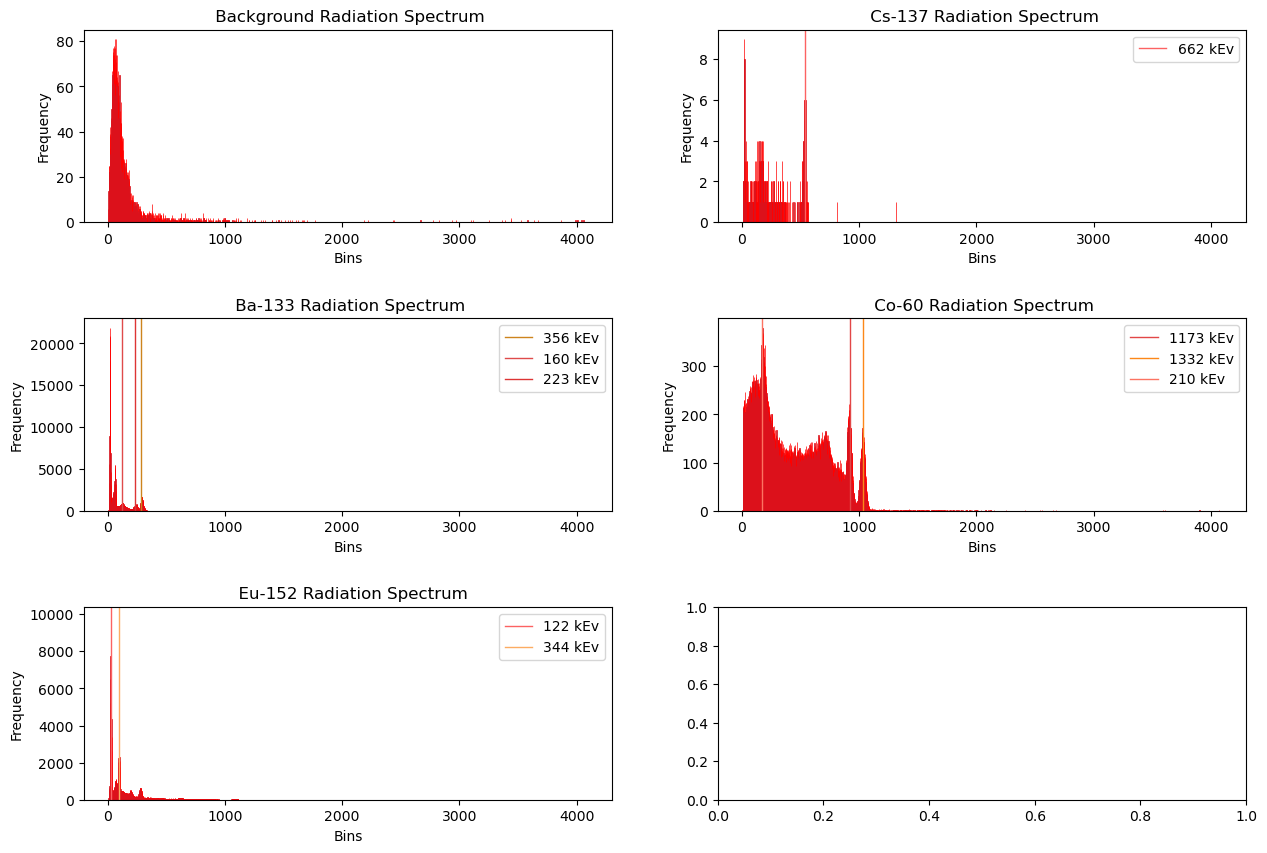

In [ ]:
from scipy.signal import find_peaks

fig, ax = plt.subplots(figsize=(15,10),nrows=3,ncols=2)
plt.subplots_adjust(hspace=0.5)

for i,data in enumerate(spectrum_data):
    
    a = int(i/2)
    b = i%2


    if i == 1:
        ax[a,b].axvline(x=540, color='#FC6262', label='662 kEv',lw=1)
        ax[a,b].legend(loc='upper right')

    elif i==2:

        ax[a,b].axvline(x=287, color="#CD841D", label='356 kEv',lw=1)
        ax[a,b].axvline(x=127, color="#DF4B4B", label='160 kEv',lw=1)
        ax[a,b].axvline(x=250, color="#DD3434", label='223 kEv',lw=1)
        ax[a,b].axvline(x=62, color="#B80F0F", label='81 kEv',lw=1)



        ax[a,b].legend(loc='upper right')


    elif i==3:
        ax[a,b].axvline(x=921, color="#E24747", label='1173 kEv',lw=1)
        ax[a,b].axvline(x=1031, color="#FC8719", label='1332 kEv',lw=1)
        ax[a,b].axvline(x=177, color="#FC7462", label='210 kEv',lw=1)


        ax[a,b].legend(loc='upper right')


    elif i==4:
        #peaks, _ = find_peaks(data, height=500, distance=30)
        ax[a,b].axvline(x=28, color="#FC6262", label='122 kEv',lw=1)
        ax[a,b].axvline(x=98, color="#E3552A", label='344 kEv',lw=1)
        ax[a,b].axvline(x=195, color="#FB9E47", label='779 kEv',lw=1)
        ax[a,b].axvline(x=282, color="#FB9E47", label='1112 kEv',lw=1)



        ax[a,b].legend(loc='upper right')


    bins = np.arange(1, data.shape[0]+1)

    ax[a,b].bar(bins, data, width=1, align='edge', edgecolor='red', linewidth=0.5)

    ax[a,b].set_xlabel('Bins')
    ax[a,b].set_ylabel('Frequency')
    ax[a,b].set_title(f' {isotopes[i]} Radiation Spectrum')
    

#From this we get

#Bin - kEv
# 540 - 662

# 287 - 358

# 921 - 1173
# 1031 - 1332
# 177 - 209.8


# 28 - 122
# 98 - 344

#Conversion from bins-> kEv -- kEv = 1.30595 * x - 25.11782
# w/ R^2 value of 0.9994


[ 27  97 195 281]
[0, 0, 0, 0, 0, 0, 1, 116, 522, 498, 432, 416, 445, 457, 613, 754, 999, 1353, 1852, 2440, 3327, 4021, 5216, 6520, 7732, 8992, 9788, 9887, 9168, 8242, 6804, 5419, 4351, 3374, 2613, 2037, 1501, 1111, 871, 664, 533, 509, 438, 432, 447, 396, 487, 488, 520, 485, 515, 546, 610, 568, 567, 606, 623, 651, 673, 799, 787, 845, 912, 954, 1017, 1017, 1028, 1078, 1047, 1099, 1100, 1052, 972, 931, 920, 859, 906, 829, 833, 814, 842, 831, 801, 878, 869, 952, 1006, 1157, 1312, 1457, 1788, 2034, 2270, 2477, 2696, 2830, 3008, 3024, 2804, 2632, 2306, 2096, 1741, 1525, 1211, 1012, 906, 735, 580, 575, 482, 461, 489, 431, 450, 430, 416, 445, 443, 449, 448, 454, 419, 437, 453, 485, 465, 445, 413, 463, 418, 461, 425, 402, 398, 399, 397, 402, 400, 356, 359, 357, 415, 353, 379, 372, 352, 365, 333, 316, 357, 380, 359, 362, 386, 343, 300, 344, 344, 347, 337, 339, 326, 331, 327, 325, 300, 317, 312, 322, 327, 361, 341, 312, 280, 296, 330, 311, 300, 306, 314, 288, 333, 364, 326, 352, 343, 381, 411, 4

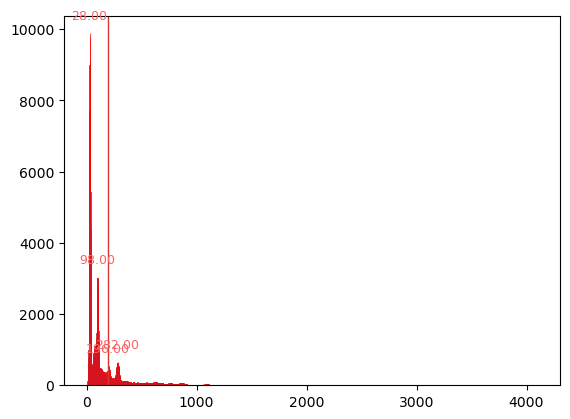

In [46]:
num=4

bins = np.arange(1, spectrum_data[num].shape[0]+1)
peaks, _ = find_peaks(spectrum_data[num], height=300, distance=70)
print(peaks)



plt.bar(bins,spectrum_data[num],width=5, align='edge', edgecolor='red', linewidth=0.5)

for j in peaks:
    plt.annotate(f"{bins[j]:.2f}", 
        xy=(bins[j], spectrum_data[num][j]), 
        xytext=(0, 10), 
        textcoords="offset points", 
        ha='center', 
        fontsize=9,
        color="#FC6262")
    
plt.axvline(x=195, color="#DD3434", label='81 kEv',lw=1)

print(spectrum_data[num].tolist())